In [1]:
import utils
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('display.max_rows', None)

# Exclusion criteria
- Check only the last two blocks
- cutoff for congruent = 60%
- cutoff for incongruent = 100% - congruent + 10%

In [4]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/' #'/Volumes/4kenneth/'
unique_subject_ids = [5, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,23,25,26,28,29,34,37,38,40,42,43,44,45,46,47]
unique_sessions = [1]

#combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, remove_reversals=False, remove_invalid_trials=True, block_isolated='block_2')#, selected_pattern='speakup')

for subject_id in unique_subject_ids:
    dataframe = combined_results_dataframe.loc[combined_results_dataframe['subject_id'] == f'sub-{subject_id:03}']

    cue = dataframe['stimuli_type'].map({1: -0.5, 2: 0.5}).to_list()
    outcome = dataframe['subjectively_correct_boolean'].astype(int).to_list()
    choice = dataframe['response'].map({'up': 1, 'down': 0}).astype(int).to_list()

    fit_dict = {'cue':cue,'outcome':outcome,'choice':choice}
    fit_result = utils.exclusion_check_models.fit_model(fit_dict)

    neg_ll_difference = fit_result['s_nll'] - fit_result['t_nll']
    print(f"Negative log-likelihood for transfer model is: {fit_result['t_nll']}")
    print(f"Negative log-likelihood for separate model is: {fit_result['s_nll']}")
    print(f'Difference for subject {subject_id} is {neg_ll_difference:.3f}')

    e_greedy_transfer_model = fit_result['t_para'][-1]
    print(f'The e-greedy value for subject {subject_id} is {e_greedy_transfer_model:.3f}')

differential_evolution step 1: f(x)= 183.15273685866197
differential_evolution step 2: f(x)= 182.3161330802254
differential_evolution step 3: f(x)= 181.39423474961526
differential_evolution step 4: f(x)= 178.69146172428353
differential_evolution step 5: f(x)= 175.21262436191628
differential_evolution step 6: f(x)= 173.69965286080037
differential_evolution step 7: f(x)= 170.00459325194262
differential_evolution step 8: f(x)= 169.88932977360983
differential_evolution step 9: f(x)= 169.87864603775503
differential_evolution step 10: f(x)= 168.9418398932693
differential_evolution step 11: f(x)= 168.40038350313293
differential_evolution step 12: f(x)= 168.40038350313293
differential_evolution step 13: f(x)= 168.40038350313293
differential_evolution step 14: f(x)= 168.34967782570573
differential_evolution step 15: f(x)= 168.18811247691264
differential_evolution step 16: f(x)= 167.96529315009195
differential_evolution step 17: f(x)= 167.8634402075968
differential_evolution step 18: f(x)= 167.8

In [3]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/' #'/Volumes/4kenneth/'
unique_subject_ids = [17]
unique_sessions = [1]

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, remove_reversals=False, remove_invalid_trials=True, block_isolated='block_2')#, selected_pattern='speakup')
combined_results_dataframe = combined_results_dataframe.sort_values(by=['stimuli_type', 'trial'], ascending=[True, True])

print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
7        7        1.747138e+09       up               False   
10      10        1.747138e+09       up                True   
11      11        1.747138e+09     down                True   
12      12        1.747138e+09       up                True   
13      13        1.747138e+09       up               False   
14      14        1.747138e+09     down               False   
15      15        1.747138e+09     down               False   
17      17        1.747138e+09       up               False   
18      18        1.747138e+09     down               False   
19      19        1.747138e+09     down                True   
20      20        1.747138e+09     down               False   
21      21        1.747138e+09     down                True   
22      22        1.747138e+09     down                True   
23      23        1.747138e+09     down               False   
24      24        1.747138e+09       up               F

# Fit learning models
To check whether participants learn the task structure, and whether they don't make too many random choices

In [4]:
run_simulation = False
participant_excluded = False
if run_simulation:
    para_true = np.array([0.25, 5.0, 0.0, 0.0, 0.1])
    cue, outcome, choice = utils.exclusion_check_models.simulate_rw(para_true, n_trial=440, seed=666)
else:
    cue = combined_results_dataframe['stimuli_type'].map({1: -0.5, 2: 0.5}).to_list()
    outcome = combined_results_dataframe['subjectively_correct'].map({'True': 1, 'False': 0}).astype(int).to_list()
    #outcome = combined_results_dataframe['subjectively_correct_boolean'].astype(int).to_list()
    choice = combined_results_dataframe['response'].map({'up': 1, 'down': 0}).astype(int).to_list()

fit_dict = {'cue':cue,'outcome':outcome,'choice':choice}

In [5]:
fit_result = utils.exclusion_check_models.fit_model(fit_dict)

differential_evolution step 1: f(x)= 200.1883847295189
differential_evolution step 2: f(x)= 199.86225741403513
differential_evolution step 3: f(x)= 199.86225741403513
differential_evolution step 4: f(x)= 199.86225741403513
differential_evolution step 5: f(x)= 199.86225741403513
differential_evolution step 6: f(x)= 199.61793590113865
differential_evolution step 7: f(x)= 199.61793590113865
differential_evolution step 8: f(x)= 199.45634323602633
differential_evolution step 9: f(x)= 199.45634323602633
differential_evolution step 10: f(x)= 199.01350699200506
differential_evolution step 11: f(x)= 198.43937751113953
Polishing solution with 'L-BFGS-B'
differential_evolution step 1: f(x)= 213.68406351468437
differential_evolution step 2: f(x)= 213.651955496577
differential_evolution step 3: f(x)= 213.6457163293573
differential_evolution step 4: f(x)= 213.6457163293573
differential_evolution step 5: f(x)= 213.6138151047146
Polishing solution with 'L-BFGS-B'


# Results explanation
t stands for transfer learning model, where participants figure out the task structure
s stands for separate learning model, where participants learn happy and angry cues separately

In the array:
- learning rate (alpha)
- Temperature
- Arroach/Avoidance bias
- Congruency effect
- e-greedy (value above 0.35 is are too many random choices)

- nll stands for negative log-likelihood, lower values indicate better model fit
According to Burnham and Anderson (2004):
- nll difference of 0-2 = no difference
- nll difference of 2-4 = moderate evidence
- nll difference > 4 = strong evidence

In [6]:
neg_ll_difference = fit_result['s_nll'] - fit_result['t_nll']
print(f"Negative log-likelihood for transfer model is: {fit_result['t_nll']}")
print(f"Negative log-likelihood for separate model is: {fit_result['s_nll']}")

if neg_ll_difference > 4:
    print(f'Participant shows strong evidence for learning behaviour\nDifference is {neg_ll_difference:.3f}')
elif neg_ll_difference > 1.5:
    print(f'Participant shows moderate evidence for learning behaviour\nDifference is {neg_ll_difference:.3f}')
else:
    print(f'Participant shows no evidence for learning behaviour\nDifference is {neg_ll_difference:.3f}')
    participant_excluded = True

Negative log-likelihood for transfer model is: 198.2039142504519
Negative log-likelihood for separate model is: 213.42566623411042
Participant shows strong evidence for learning behaviour
Difference is 15.222


In [7]:
e_greedy_transfer_model = fit_result['t_para'][-1]

if e_greedy_transfer_model < 0.35:
    print(f'Participant shows little to no evidence for random choices\nThe e-greedy value is {e_greedy_transfer_model:.3f}')
else:
    print(f'Participant gave too many random choices\nThe e-greedy value is {e_greedy_transfer_model:.3f}')
    participant_excluded = True

Participant gave too many random choices
The e-greedy value is 0.559


# Responses over the entire experiment

In [8]:
# Jitter vertically to make the lines easier to read when overlapping
dataframe = combined_results_dataframe.dropna(subset=['response'])
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'])
dataframe['trial_separated'] = (
    dataframe
    .groupby(['subject_id', 'session', 'stimuli_type'])
    .cumcount()
    + 1
)
dataframe = utils.analysis_functions.replace_strings_with_integers(dataframe,
                                                                                    {'up': 100, 'down': 0},
                                                                                    'response',
                                                                                    'response_int')
dataframe['response_rolling_average'] = (
    dataframe
    .groupby('stimuli_type')['response_int']
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

stimuli_list = ['Angry', 'Happy']
colour_list = ['red', 'green']

stim_types = dataframe['stimuli_type'].unique()
n_types = len(stim_types)

# create one subplot per stimuli_type
fig, axes = plt.subplots(n_types, 1,
                         figsize=(15, 4 * n_types),
                         sharex=True)

# if there's only one type, axes is not a list
if n_types == 1:
    axes = [axes]

for ax, stim in zip(axes, stim_types):
    sub = dataframe[dataframe['stimuli_type'] == stim]
    ax.plot(sub['trial_separated'], sub['probability_condition'], linestyle='-',
            label=f'{stimuli_list[stim-1]} probability condition', color=colour_list[stim-1])
    ax.plot(sub['trial_separated'], sub['response_rolling_average'],
            marker='s', linestyle='--',
            label='Response rolling average', color='#5688C7')
    ax.set_title(f'{stimuli_list[stim-1]} stimuli')
    ax.set_ylabel('Chance of avoid response [%]')
    ax.legend(loc='best')

# common x-axis label
axes[-1].set_xlabel('Trial')

plt.tight_layout()
plt.show()

KeyError: 'subject_id'

# Reaction time check

['/Volumes/project/3025011.02/raw/sub-017/ses-mri01/beh/behavioural_output_sub-017_session-01_dummy_2025-05-13_14-06-09.csv']
     stimuli_type  probability_condition   congruency
0               2                     50    undefined
1               1                     50    undefined
2               1                     50    undefined
3               1                     50    undefined
4               2                     50    undefined
5               2                     50    undefined
6               1                     50    undefined
7               1                     20  incongruent
8               2                     50    undefined
9               2                     80  incongruent
10              2                     80  incongruent
11              1                     20  incongruent
12              2                     80  incongruent
13              1                     20  incongruent
14              2                     80  incongruent
15        

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:613: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['objectively_correct_boolean'] = dataframe['objectively_correct'].replace(mapping)
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:615: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['subjectively_correct_boolean'] = dataframe['subjectively_correct'].replace(mapping)
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:651: FutureWarning

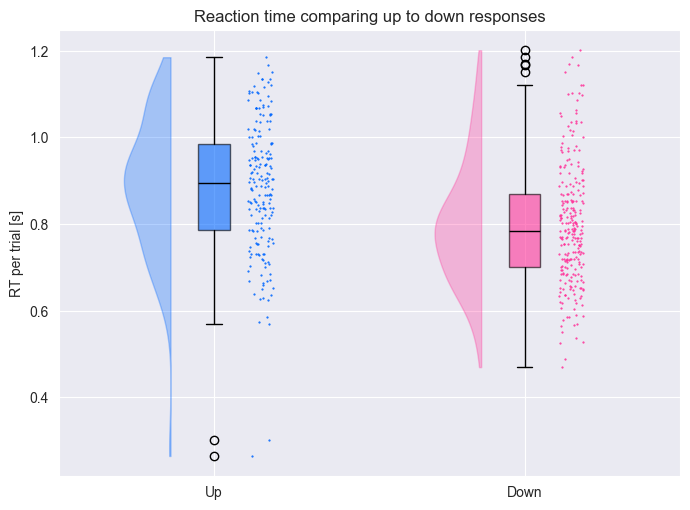

In [77]:
# Re-import data to check RT effects
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, remove_invalid_trials=False)

# Print percentage of non-response trials
non_response_trials = combined_results_dataframe[combined_results_dataframe['response'].isna()]
percentage_responses = len(non_response_trials)/len(combined_results_dataframe)*100

if percentage_responses > 10:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
      'This means that the participant responded in less than 90% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
          'Include the participant.\n')

joystick_locked_trials = combined_results_dataframe[combined_results_dataframe['RT_s'] < 0.05]
percentage_joystick_locked = len(joystick_locked_trials)/len(combined_results_dataframe)*100

if percentage_joystick_locked > 10:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
      'This means that the participant locked the joystick in more than 10% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
          'Include the participant.\n')

# Plot reaction time
happy_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'up']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'down']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Up', 'Down'])  # Set text labels.
plt.ylabel('RT per trial [s]')
plot_name = 'Reaction time comparing up to down responses'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.show()

In [78]:
if participant_excluded:
    raise Exception('Participant excluded on behavioural criteria')

Exception: Participant excluded on behavioural criteria

# Adjust simulations
- Check MI Skin and Brain to see if it's below 1.9
- Check CEM43 skin and brain to see if it's below 0.25
- Check if maxT skin and brain exceeds 39 degrees Celsius

In [10]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'
stimulation_limits_exceeded = False

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

simulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)

simulation_output_full_filenames = [s for s in simulation_output_full_filenames if f'sub-{unique_subject_ids[0]:03}' in s]
if not simulation_output_full_filenames:
    raise Exception('No simulations found')
simulation_output_full_filenames.sort()
print(simulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_2_1/sub-005/sub-005_layered_output_table_target_2_1_dc20_strength_3_dense.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_1/sub-005/sub-005_layered_output_table_target_2_1_dc20_strength_3_sparse.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_2/sub-005/sub-005_layered_output_table_target_2_2_dc20_strength_3_dense.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_2/sub-005/sub-005_layered_output_table_target_2_2_dc20_strength_3_sparse.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_3/sub-005/sub-005_layered_output_table_target_2_3_dc20_strength_3_dense.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_3/sub-005/sub-005_layered_output_table_target_2_3_dc20_strength_3_sparse.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_4/sub-005/sub-005_layered_output_table_target_2_4_dc20_strength_3_dense.csv', '/Volumes

### Check if target names are missing

In [11]:
expected = [f"target_{i}_{j}"
            for i in range(1, 4)
            for j in range(1, 7)]

# find which expected names are missing
missing = [t for t in expected
           if not any(t in filename for filename in simulation_output_full_filenames)]

if missing:
    print("Missing target names:")
    for name in missing:
        print("  -", name)
else:
    print("All target names 1_1 through 3_6 are present.")

Missing target names:
  - target_1_1
  - target_1_2
  - target_1_3
  - target_1_4
  - target_1_5
  - target_1_6


In [12]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for simulation_output_full_filename in simulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(simulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]

    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')

    # Extract the subject_id and target from the filename parts
    subject_id = stimulation_output_filename_parts[0]
    target = '_'.join(stimulation_output_filename_parts[4:7])

    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(simulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {simulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the intensity and duty cycle based on the filename parts
    df['target'] = target
    if 'target_3' in target:
        df['intensity'] = 'strength_1'
        df['duty_cycle'] = 'dc20'
    else:
        duty_cycle = stimulation_output_filename_parts[7]
        intensity = '_'.join(stimulation_output_filename_parts[8:10])
        df['intensity'] = intensity
        df['duty_cycle'] = duty_cycle

    # Append the dataframe to the list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

    subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0            5   20.97227                   20.972270            13.500000   
1            5   17.37236                   17.372360            13.500000   
2            5   17.44859                   16.827670             8.514693   
3            5   17.45977                   16.625590             8.500000   
4            5   20.81111                   20.811110            17.007351   
5            5   20.81111                   20.811110            17.007351   
6            5   20.66646                   20.666460            17.528548   
7            5   20.66646                   20.666460            17.528548   
8            5   29.27273                   20.628010             4.500000   
9            5   27.65347                   20.730900             4.527693   
10           5   25.36325                   25.363250            15.008331   
11           5   25.54544                   25.545440           

In [13]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'max_pressure_brain','max_pressure_skull','max_pressure_skin',
     'riseT_brain', 'riseT_skull', 'riseT_skin','isppa_at_target',
     'max_Isppa','half_max_ISPPA_volume_brain','avg_isppa_around_target',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

    subject_id      target intensity duty_cycle  max_Isppa_after_exit_plane  \
0            5  target_2_1        81        20%                   20.972270   
1            5  target_2_1        81        20%                   17.372360   
2            5  target_2_2        81        20%                   16.827670   
3            5  target_2_2        81        20%                   16.625590   
4            5  target_2_3        81        20%                   20.811110   
5            5  target_2_3        81        20%                   20.811110   
6            5  target_2_4        81        20%                   20.666460   
7            5  target_2_4        81        20%                   20.666460   
8            5  target_2_5        81        20%                   20.628010   
9            5  target_2_5        81        20%                   20.730900   
10           5  target_2_6        81        20%                   25.363250   
11           5  target_2_6        81        20%     

In [14]:
# Create mask for rows where either of the limits are exceeded
MI_mask = (
    (stimulation_output['max_MI_skin'] > 1.9) |
    (stimulation_output['max_MI_brain'] > 1.9)
)
CEM43_mask = (
    (stimulation_output['CEM43_skin'] > 0.25) |
    (stimulation_output['CEM43_brain'] > 0.25)
)
temperature_mask = (
    (stimulation_output['maxT_skin'] > 39) |
    (stimulation_output['maxT_brain'] > 39)
)
thermal_modulation_mask = (
    (stimulation_output['maxT_brain'] > 38)
)

# Filter the rows and select the desired columns
simulations_exceeding_MI = stimulation_output[MI_mask]
simulations_exceeding_CEM43 = stimulation_output[CEM43_mask]
simulations_exceeding_temperature = stimulation_output[temperature_mask]
simulations_exceeding_thermal_modulation = stimulation_output[thermal_modulation_mask]

# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_MI.iterrows():
    exceeded = {}
    if row['max_MI_skin'] > 1.9:
        exceeded['max_MI_skin'] = row['max_MI_skin']
    if row['max_MI_brain'] > 1.9:
        exceeded['max_MI_brain'] = row['max_MI_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the MI limits in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

In [15]:
# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_CEM43.iterrows():
    exceeded = {}
    if row['CEM43_skin'] > 0.25:
        exceeded['CEM43_skin'] = row['CEM43_skin']
    if row['CEM43_brain'] > 0.25:
        exceeded['CEM43_brain'] = row['CEM43_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the CEM43 limits in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

In [16]:
# Print the rows where the temperature rise is exceeded
for _, row in simulations_exceeding_temperature.iterrows():
    exceeded = {}
    if row['maxT_skin'] > 39:
        exceeded['maxT_skin'] = row['maxT_skin']
    if row['maxT_brain'] > 39:
        exceeded['maxT_brain'] = row['maxT_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the temperature limits in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

target_3_6 with an intensity of 35W/cm2 and a duty_cycle of 20%, exceeded the temperature limits in the following tissues: {'maxT_skin': 39.00943}


In [17]:
# Print the rows where the temperature rise is high
for _, row in simulations_exceeding_thermal_modulation.iterrows():
    exceeded = {}
    if row['maxT_brain'] > 38:
        exceeded['maxT_brain'] = row['maxT_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, might cause heating neuromodulation in the following tissues: {exceeded}")

target_2_2 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.60152}
target_2_2 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.63534}
target_2_3 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.12925}
target_2_3 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.13038}
target_2_4 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.75945}
target_2_4 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.75797}
target_2_5 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neu

In [18]:
if participant_excluded:
    raise Exception('\nParticipant excluded on behavioural criteria.')
elif stimulation_limits_exceeded:
    raise Exception('\nParticipant exceeds stimulation thresholds.\n'
                    'Lower the intensity')

Exception: 
Participant exceeds stimulation thresholds.
Lower the intensity